<a href="https://colab.research.google.com/github/jananibabu17112004-ctrl/variant-pathogenicity-streamlit17/blob/main/Model1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas biopython torch scikit-learn tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 18.5 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
from Bio import SeqIO
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [3]:
BASE_DIR = "transssv_colab"
DATA_DIR = f"{BASE_DIR}/data"
MODEL_DIR = f"{BASE_DIR}/models"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Folders ready")


Folders ready


In [4]:
CLINVAR_URL = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz"

chunks = pd.read_csv(
    CLINVAR_URL,
    sep="\t",
    compression="gzip",
    usecols=[
        "Chromosome",
        "Start",
        "ClinicalSignificance"
    ],
    chunksize=50_000
)

valid = []

for chunk in chunks:
    chunk = chunk[chunk["ClinicalSignificance"].isin(["Pathogenic", "Benign"])]
    valid.append(chunk)
    if len(valid) == 2:  # keep VERY small
        break

clinvar_df = pd.concat(valid).dropna()

clinvar_path = f"{DATA_DIR}/clinvar_chunk.csv"
clinvar_df.to_csv(clinvar_path, index=False)

print("ClinVar saved:", clinvar_df.shape)


ClinVar saved: (44914, 3)


In [5]:
!wget -O transssv_colab/data/hg38.fa.gz https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
!gunzip -f transssv_colab/data/hg38.fa.gz


--2026-04-21 18:09:37--  https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
Resolving hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)|128.114.119.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 983659424 (938M) [application/x-gzip]
Saving to: ‘transssv_colab/data/hg38.fa.gz’

transssv_colab/data 100%[===================>] 938.09M  40.0MB/s    in 30s     

2026-04-21 18:10:08 (31.1 MB/s) - ‘transssv_colab/data/hg38.fa.gz’ saved [983659424/983659424]



In [6]:
hg38_path = f"{DATA_DIR}/hg38.fa"
reference = SeqIO.to_dict(SeqIO.parse(hg38_path, "fasta"))

print("hg38 chromosomes loaded:", len(reference))


hg38 chromosomes loaded: 455


In [7]:
BASE2IDX = {"A":0, "C":1, "G":2, "T":3, "N":4}

def one_hot_encode(seq, max_len):
    out = [[0]*5 for _ in range(max_len)]
    for i, b in enumerate(seq[:max_len]):
        out[i][BASE2IDX.get(b, 4)] = 1
    return out


In [8]:
class ClinVarDataset(Dataset):
    def __init__(self, csv_path, reference, context=10):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.ref = reference
        self.context = context

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        chrom = f"chr{row.Chromosome}"
        if chrom not in self.ref:
            return self.__getitem__((idx + 1) % len(self.df))

        pos = int(row.Start)
        seq = self.ref[chrom].seq

        start = max(0, pos - self.context)
        end = pos + self.context

        context_seq = str(seq[start:end])
        x = one_hot_encode(context_seq, 2 * self.context)

        y = 1 if row.ClinicalSignificance == "Pathogenic" else 0

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y)


In [9]:
class TransSSV(nn.Module):
    def __init__(self):
        super().__init__()

        self.embed = nn.Linear(5, 128)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=4,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.embed(x)
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.fc(x)


In [13]:
train_dataset = ClinVarDataset(clinvar_path, reference)

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
from torch.utils.data import DataLoader

# assuming you already created a Dataset object
# example: train_dataset

loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

EPOCHS = 5


In [16]:
model = TransSSV().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 5 # keep small for CPU

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    loop = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for x, y in loop:
        x = x.to(device)
        y = y.to(device).float()

        optimizer.zero_grad()
        out = model(x).view(-1)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Avg Loss: {total_loss/len(loader):.4f}")


Epoch 1/5: 100%|██████████| 1404/1404 [00:22<00:00, 63.14it/s, loss=0.235]


Epoch 1 Avg Loss: 0.3668


Epoch 2/5: 100%|██████████| 1404/1404 [00:20<00:00, 69.24it/s, loss=0.247]


Epoch 2 Avg Loss: 0.3657


Epoch 3/5: 100%|██████████| 1404/1404 [00:20<00:00, 68.55it/s, loss=0.116]


Epoch 3 Avg Loss: 0.3658


Epoch 4/5: 100%|██████████| 1404/1404 [00:20<00:00, 69.30it/s, loss=0.236]


Epoch 4 Avg Loss: 0.3655


Epoch 5/5: 100%|██████████| 1404/1404 [00:19<00:00, 71.40it/s, loss=0.346]

Epoch 5 Avg Loss: 0.3657


In [17]:
model.eval()

preds = []
labels = []

with torch.no_grad():
    for x, y in tqdm(loader, desc="Evaluating"):
        x = x.to(device)

        out = model(x).view(-1)
        pred_batch = (out > 0.5).int().cpu()

        for p, t in zip(pred_batch, y):
            preds.append(int(p.item()))
            labels.append(int(t.item()))



Evaluating: 100%|██████████| 1404/1404 [00:08<00:00, 160.51it/s]


In [18]:
def predict_variant(chromosome, position):
    chrom = f"chr{chromosome}"

    if chrom not in reference:
        return "Invalid chromosome"

    seq = reference[chrom].seq
    start = max(0, position - 10)
    end = position + 10

    context_seq = str(seq[start:end])
    x = torch.tensor([one_hot_encode(context_seq, 20)], dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        prob = model(x).item()

    return prob, "Pathogenic" if prob > 0.5 else "Benign"


In [ ]:
model_path = f"{MODEL_DIR}/transssv_model.pth"
torch.save(model.state_dict(), model_path)

print("Model saved at:", model_path)


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc = accuracy_score(labels, preds)
prec = precision_score(labels, preds, zero_division=0)
rec = recall_score(labels, preds, zero_division=0)
f1 = f1_score(labels, preds, zero_division=0)
cm = confusion_matrix(labels, preds)

print("\n===== Evaluation Metrics =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nConfusion Matrix")
print(cm)



===== Evaluation Metrics =====
Accuracy  : 0.8808
Precision : 0.8808
Recall    : 1.0000
F1 Score  : 0.9366

Confusion Matrix
[[    0  5353]
 [    0 39561]]


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)


In [21]:
RESULTS_DIR = f"{BASE_DIR}/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Results folder ready")


Results folder ready


Confusion Matrix:
[[    0  5353]
 [    0 39561]]


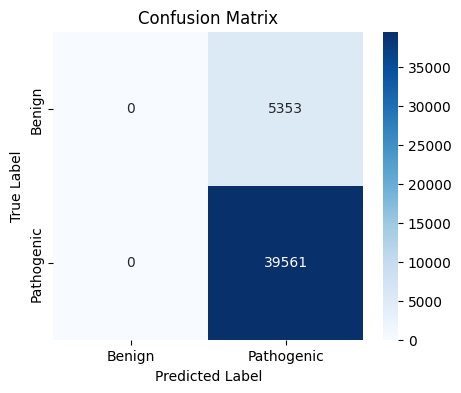

Saved: transssv_colab/results/confusion_matrix.png


In [22]:
cm = confusion_matrix(labels, preds)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Pathogenic"],
    yticklabels=["Benign", "Pathogenic"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

cm_path = f"{RESULTS_DIR}/confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)


In [23]:
# Get probabilities
model.eval()
probs = []

with torch.no_grad():
    for x, _ in tqdm(loader, desc="Collecting probabilities"):
        x = x.to(device)
        out = model(x).view(-1)
        probs.extend(out.cpu().tolist())


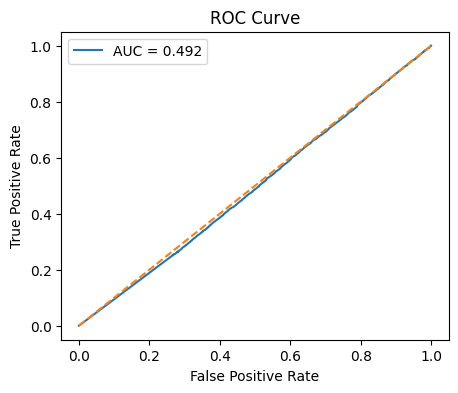

Saved: transssv_colab/results/roc_curve.png


In [24]:
fpr, tpr, _ = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

roc_path = f"{RESULTS_DIR}/roc_curve.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", roc_path)


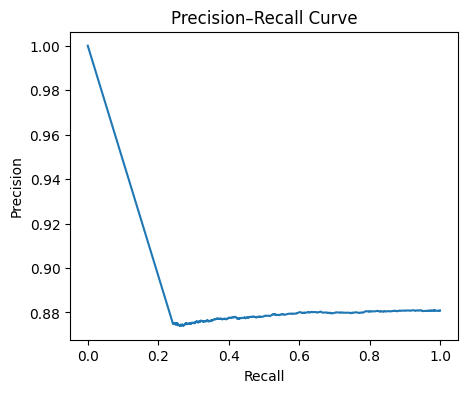

Saved: transssv_colab/results/precision_recall_curve.png


In [25]:
precision, recall, _ = precision_recall_curve(labels, probs)

plt.figure(figsize=(5,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")

pr_path = f"{RESULTS_DIR}/precision_recall_curve.png"
plt.savefig(pr_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pr_path)


In [26]:
metrics_path = f"{RESULTS_DIR}/metrics.txt"

with open(metrics_path, "w") as f:
    f.write("Evaluation Metrics\n")
    f.write("------------------\n")
    f.write(f"Accuracy  : {acc:.4f}\n")
    f.write(f"Precision : {prec:.4f}\n")
    f.write(f"Recall    : {rec:.4f}\n")
    f.write(f"F1 Score  : {f1:.4f}\n")
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("Metrics saved to:", metrics_path)


Metrics saved to: transssv_colab/results/metrics.txt


In [27]:
from google.colab import files

files.download(cm_path)
files.download(roc_path)
files.download(pr_path)
files.download(metrics_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ls transssv_colab/models



In [ ]:
from google.colab import files

files.download("transssv_colab/models/transssv_model.pth")


In [ ]:
from google.colab import files
files.download("hg38.fa.gz")


In [ ]:
!ls


In [ ]:
!find /content -name "hg38*"


In [ ]:
from google.colab import files
files.download("/content/transssv_colab/data/hg38.fa")


In [28]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
values = [accuracy, precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.ylim(0, 1)
plt.title("Evaluation Metrics")
plt.show()


NameError: name 'accuracy' is not defined